In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from scipy.stats import spearmanr, kendalltau

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from xgboost import XGBRegressor

In [5]:
PROJECT_ROOT = Path.cwd().parent.parent

FEATURE_FILE = (
    PROJECT_ROOT
    / "data"
    / "features"
    / "f1_features.csv"
)

print(PROJECT_ROOT)
print(FEATURE_FILE)
print(FEATURE_FILE.exists())

c:\MY WORK\Projects\F1-prediction-model
c:\MY WORK\Projects\F1-prediction-model\data\features\f1_features.csv
True


In [6]:
df = pd.read_csv(FEATURE_FILE)

print("Shape:", df.shape)
print("Years:", df["year"].min(), "-", df["year"].max())
print("Races:", df["raceId"].nunique())

df.head()

Shape: (3810, 59)
Years: 2018 - 2026
Races: 189


,raceId,year,round,circuitId,driverId,constructorId,fp1_position,fp2_position,fp3_position,fp1_best_lap_seconds,...,sprint_grid,sprint_position,sprint_points,sprint_laps,sprint_is_dnf,has_sprint,qualifying_vs_teammate,grid_vs_teammate,practice_vs_teammate,sprint_vs_teammate
0,989,2018,1,1,1,131,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0,10.0,15.0,NaN,NaN
1,989,2018,1,1,4,1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0,12.0,11.0,NaN,NaN
2,989,2018,1,1,8,6,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0,3.0,3.0,NaN,NaN
3,989,2018,1,1,20,6,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0,2.0,2.0,NaN,NaN
4,989,2018,1,1,154,210,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0,6.0,5.0,NaN,NaN


In [7]:
TARGET = "finish_position"

print("Target:", TARGET)
print("Missing targets:", df[TARGET].isna().sum())
print("Usable rows:", df[TARGET].notna().sum())

df[TARGET].describe()

Target: finish_position
Missing targets: 522
Usable rows: 3288


count    3288.000000
mean        9.288625
std         5.163205
min         1.000000
25%         5.000000
50%         9.000000
75%        14.000000
max        22.000000
Name: finish_position, dtype: float64

In [8]:
missing = (
    df.isna()
    .sum()
    .sort_values(ascending=False)
)

missing[missing > 0].head(30)

sprint_vs_teammate           3282
sprint_position              3254
fp2_best_lap_seconds         3238
fp2_position                 3238
fp2_laps                     3238
fp3_best_lap_seconds         3235
fp3_laps                     3235
fp3_position                 3235
sprint_grid                  3220
sprint_points                3220
sprint_is_dnf                3220
sprint_laps                  3220
fp1_position                 3062
fp1_laps                     3062
fp1_best_lap_seconds         3062
practice_vs_teammate         3004
practice_avg_lap_seconds     3002
practice_best_position       3002
practice_avg_position        3002
q3_seconds                   1977
q3_gap_to_pole               1977
driver_circuit_avg_finish    1274
q2_seconds                   1028
finish_position               522
q1_seconds                     73
driver_avg_finish_L3           61
driver_avg_finish_L5           53
driver_avg_finish_L10          53
driver_win_rate_L10            44
driver_podium_

In [9]:
model_df = df[df[TARGET].notna()].copy()

model_df = model_df.sort_values(
    ["year", "round", "raceId", "driverId"]
).reset_index(drop=True)

print("Model rows:", len(model_df))
print("Years:", model_df["year"].min(), "-", model_df["year"].max())
print("Races:", model_df["raceId"].nunique())

Model rows: 3288
Years: 2018 - 2026
Races: 189


In [10]:
FEATURES = [
    "qualifying_position",
    "q1_seconds",
    "q2_seconds",
    "q3_seconds",
    "q3_gap_to_pole",

    "driver_avg_finish_L3",
    "driver_avg_finish_L5",
    "driver_avg_finish_L10",
    "driver_points_L5",
    "driver_dnf_rate_L10",
    "driver_podium_rate_L10",
    "driver_win_rate_L10",

    "constructor_avg_finish_L5",
    "constructor_points_L5",
    "constructor_dnf_rate_L10",

    "driver_points_before_race",
    "driver_championship_position",

    "constructor_points_before_race",
    "constructor_championship_position",

    "driver_circuit_avg_finish",
    "driver_circuit_races",

    "season_progress",

    "qualifying_vs_teammate",
    "grid_vs_teammate",
]

In [11]:
X = model_df[FEATURES]
y = model_df[TARGET]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3288, 24)
y shape: (3288,)


In [12]:
FOLDS = [
    (2022, 2023),
    (2023, 2024),
    (2024, 2025),
    (2025, 2026),
]

FOLDS

[(2022, 2023), (2023, 2024), (2024, 2025), (2025, 2026)]

In [13]:
def evaluate_model(model, X_data, y_data, data):
    
    fold_results = []
    all_predictions = []

    for train_end, test_year in FOLDS:

        train_mask = data["year"] <= train_end
        test_mask = data["year"] == test_year

        X_train = X_data.loc[train_mask]
        y_train = y_data.loc[train_mask]

        X_test = X_data.loc[test_mask]
        y_test = y_data.loc[test_mask]

        print("=" * 60)
        print(f"TRAIN <= {train_end}  |  TEST = {test_year}")
        print("=" * 60)

        print("Train rows:", len(X_train))
        print("Test rows :", len(X_test))

        # Train
        model.fit(X_train, y_train)

        # Predict
        predictions = model.predict(X_test)

        # Metrics
        mae = mean_absolute_error(
            y_test,
            predictions
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_test,
                predictions
            )
        )

        spearman = spearmanr(
            y_test,
            predictions
        ).statistic

        kendall = kendalltau(
            y_test,
            predictions
        ).statistic

        print(f"MAE      : {mae:.4f}")
        print(f"RMSE     : {rmse:.4f}")
        print(f"Spearman : {spearman:.4f}")
        print(f"Kendall  : {kendall:.4f}")
        print()

        fold_results.append({
            "train_end_year": train_end,
            "test_year": test_year,
            "train_rows": len(X_train),
            "test_rows": len(X_test),
            "MAE": mae,
            "RMSE": rmse,
            "Spearman": spearman,
            "Kendall": kendall
        })

        fold_predictions = data.loc[
            test_mask,
            [
                "raceId",
                "year",
                "round",
                "driverId",
                TARGET
            ]
        ].copy()

        fold_predictions["predicted_finish"] = predictions

        all_predictions.append(
            fold_predictions
        )

    results = pd.DataFrame(fold_results)

    summary = pd.DataFrame([{
        "MAE": results["MAE"].mean(),
        "RMSE": results["RMSE"].mean(),
        "Spearman": results["Spearman"].mean(),
        "Kendall": results["Kendall"].mean()
    }])

    predictions_df = pd.concat(
        all_predictions,
        ignore_index=True
    )

    return results, summary, predictions_df

In [14]:
ridge = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

In [15]:
ridge_results, ridge_summary, ridge_predictions = evaluate_model(
    ridge,
    X,
    y,
    model_df
)

TRAIN <= 2022  |  TEST = 2023
Train rows: 1761
Test rows : 386
MAE      : 2.3556
RMSE     : 3.0785
Spearman : 0.8032
Kendall  : 0.6270

TRAIN <= 2023  |  TEST = 2024
Train rows: 2147
Test rows : 431
MAE      : 2.2202
RMSE     : 3.0134
Spearman : 0.8257
Kendall  : 0.6543

TRAIN <= 2024  |  TEST = 2025
Train rows: 2578
Test rows : 424
MAE      : 2.5059
RMSE     : 3.2957
Spearman : 0.7704
Kendall  : 0.6049

TRAIN <= 2025  |  TEST = 2026
Train rows: 3002
Test rows : 286
MAE      : 2.3661
RMSE     : 3.1708
Spearman : 0.8044
Kendall  : 0.6457



In [16]:
ridge_summary

,MAE,RMSE,Spearman,Kendall
0,2.361955,3.139586,0.800949,0.63299


In [17]:
xgb_baseline = XGBRegressor(
    objective="reg:squarederror",

    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,

    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,

    reg_alpha=0.1,
    reg_lambda=1.0,

    random_state=42,
    n_jobs=-1
)

In [18]:
xgb_results, xgb_summary, xgb_predictions = evaluate_model(
    xgb_baseline,
    X,
    y,
    model_df
)

TRAIN <= 2022  |  TEST = 2023
Train rows: 1761
Test rows : 386
MAE      : 2.6157
RMSE     : 3.3432
Spearman : 0.7593
Kendall  : 0.5740

TRAIN <= 2023  |  TEST = 2024
Train rows: 2147
Test rows : 431
MAE      : 2.3263
RMSE     : 3.1851
Spearman : 0.8010
Kendall  : 0.6256

TRAIN <= 2024  |  TEST = 2025
Train rows: 2578
Test rows : 424
MAE      : 2.5585
RMSE     : 3.3849
Spearman : 0.7559
Kendall  : 0.5861

TRAIN <= 2025  |  TEST = 2026
Train rows: 3002
Test rows : 286
MAE      : 2.2840
RMSE     : 3.1476
Spearman : 0.8124
Kendall  : 0.6529



In [20]:
xgb_summary

,MAE,RMSE,Spearman,Kendall
0,2.446125,3.265228,0.782149,0.609657


In [21]:
importance = pd.Series(
    xgb_baseline.feature_importances_,
    index=FEATURES
).sort_values(ascending=False)

importance

qualifying_position                  0.453314
constructor_points_L5                0.067091
driver_podium_rate_L10               0.061306
driver_avg_finish_L10                0.058056
q3_gap_to_pole                       0.053401
constructor_avg_finish_L5            0.036645
driver_points_L5                     0.031579
constructor_championship_position    0.021448
driver_avg_finish_L5                 0.019545
driver_points_before_race            0.017662
driver_championship_position         0.016366
q2_seconds                           0.016203
constructor_points_before_race       0.014796
q3_seconds                           0.013519
season_progress                      0.013005
driver_avg_finish_L3                 0.012905
q1_seconds                           0.012815
driver_circuit_avg_finish            0.012046
driver_win_rate_L10                  0.011952
driver_circuit_races                 0.011835
constructor_dnf_rate_L10             0.011392
qualifying_vs_teammate            

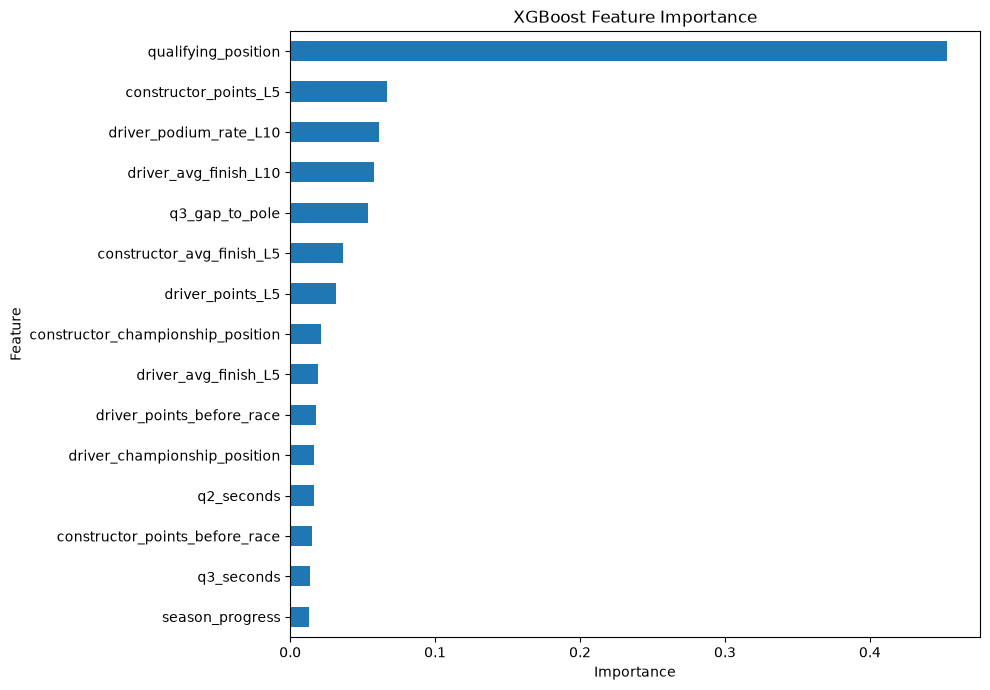

In [22]:
top_features = importance.head(15).sort_values()

plt.figure(figsize=(10, 7))
top_features.plot(kind="barh")

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [23]:
FEATURE_GROUPS = {

    "qualifying": [
        "qualifying_position",
        "q1_seconds",
        "q2_seconds",
        "q3_seconds",
        "q3_gap_to_pole",
        "qualifying_vs_teammate",
        "grid_vs_teammate",
    ],

    "driver_form": [
        "driver_avg_finish_L3",
        "driver_avg_finish_L5",
        "driver_avg_finish_L10",
        "driver_points_L5",
        "driver_dnf_rate_L10",
        "driver_podium_rate_L10",
        "driver_win_rate_L10",
    ],

    "constructor_form": [
        "constructor_avg_finish_L5",
        "constructor_points_L5",
        "constructor_dnf_rate_L10",
    ],

    "championship": [
        "driver_points_before_race",
        "driver_championship_position",
        "constructor_points_before_race",
        "constructor_championship_position",
        "season_progress",
    ],

    "circuit_history": [
        "driver_circuit_avg_finish",
        "driver_circuit_races",
    ],
}

In [24]:
FEATURE_GROUPS["non_qualifying"] = (
    FEATURE_GROUPS["driver_form"]
    + FEATURE_GROUPS["constructor_form"]
    + FEATURE_GROUPS["championship"]
    + FEATURE_GROUPS["circuit_history"]
)

In [25]:
FEATURE_GROUPS["all"] = FEATURES

In [26]:
for name, features in FEATURE_GROUPS.items():
    print(f"{name}: {len(features)} features")

qualifying: 7 features
driver_form: 7 features
constructor_form: 3 features
championship: 5 features
circuit_history: 2 features
non_qualifying: 17 features
all: 24 features


In [ ]:
def run_xgb_experiment(feature_list, name):
    
    X_exp = model_df[feature_list]

    model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=500,
        learning_rate=0.03,
        max_depth=4,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1
    )

    results, summary, predictions = evaluate_model(
        model,
        X_exp,
        y,
        model_df
    )

    summary["experiment"] = name

    return results, summary, predictions

In [28]:
experiment_results = []
experiment_summaries = {}

for name, feature_list in FEATURE_GROUPS.items():

    print("\n" + "=" * 70)
    print(f"RUNNING EXPERIMENT: {name}")
    print("=" * 70)

    results, summary, predictions = run_xgb_experiment(
        feature_list,
        name
    )

    experiment_results.append(summary)
    experiment_summaries[name] = {
        "results": results,
        "predictions": predictions
    }


RUNNING EXPERIMENT: qualifying
TRAIN <= 2022  |  TEST = 2023
Train rows: 1761
Test rows : 386
MAE      : 2.7953
RMSE     : 3.6158
Spearman : 0.7226
Kendall  : 0.5425

TRAIN <= 2023  |  TEST = 2024
Train rows: 2147
Test rows : 431
MAE      : 2.3931
RMSE     : 3.2822
Spearman : 0.7968
Kendall  : 0.6217

TRAIN <= 2024  |  TEST = 2025
Train rows: 2578
Test rows : 424
MAE      : 2.6153
RMSE     : 3.5321
Spearman : 0.7368
Kendall  : 0.5692

TRAIN <= 2025  |  TEST = 2026
Train rows: 3002
Test rows : 286
MAE      : 2.3114
RMSE     : 3.1260
Spearman : 0.8149
Kendall  : 0.6548


RUNNING EXPERIMENT: driver_form
TRAIN <= 2022  |  TEST = 2023
Train rows: 1761
Test rows : 386
MAE      : 2.9414
RMSE     : 3.7310
Spearman : 0.6865
Kendall  : 0.4963

TRAIN <= 2023  |  TEST = 2024
Train rows: 2147
Test rows : 431
MAE      : 2.7556
RMSE     : 3.5237
Spearman : 0.7352
Kendall  : 0.5446

TRAIN <= 2024  |  TEST = 2025
Train rows: 2578
Test rows : 424
MAE      : 3.0582
RMSE     : 3.9295
Spearman : 0.6348
Ke

In [ ]:
experiment_results = []
experiment_summaries = {}

for name, feature_list in FEATURE_GROUPS.items():

    print("\n" + "=" * 70)
    print(f"RUNNING EXPERIMENT: {name}")
    print("=" * 70)

    results, summary, predictions = run_xgb_experiment(
        feature_list,
        name
    )

    experiment_results.append(summary)
    experiment_summaries[name] = {
        "results": results,
        "predictions": predictions
    }


RUNNING EXPERIMENT: qualifying
TRAIN <= 2022  |  TEST = 2023
Train rows: 1761
Test rows : 386
MAE      : 2.7953
RMSE     : 3.6158
Spearman : 0.7226
Kendall  : 0.5425

TRAIN <= 2023  |  TEST = 2024
Train rows: 2147
Test rows : 431
MAE      : 2.3931
RMSE     : 3.2822
Spearman : 0.7968
Kendall  : 0.6217

TRAIN <= 2024  |  TEST = 2025
Train rows: 2578
Test rows : 424
MAE      : 2.6153
RMSE     : 3.5321
Spearman : 0.7368
Kendall  : 0.5692

TRAIN <= 2025  |  TEST = 2026
Train rows: 3002
Test rows : 286
MAE      : 2.3114
RMSE     : 3.1260
Spearman : 0.8149
Kendall  : 0.6548


RUNNING EXPERIMENT: driver_form
TRAIN <= 2022  |  TEST = 2023
Train rows: 1761
Test rows : 386
MAE      : 2.9414
RMSE     : 3.7310
Spearman : 0.6865
Kendall  : 0.4963

TRAIN <= 2023  |  TEST = 2024
Train rows: 2147
Test rows : 431
MAE      : 2.7556
RMSE     : 3.5237
Spearman : 0.7352
Kendall  : 0.5446

TRAIN <= 2024  |  TEST = 2025
Train rows: 2578
Test rows : 424
MAE      : 3.0582
RMSE     : 3.9295
Spearman : 0.6348
Ke

In [29]:
print(X)

      qualifying_position  q1_seconds  q2_seconds  q3_seconds  q3_gap_to_pole  \
0                     1.0      82.824      82.051      81.164           0.000   
1                    11.0      83.597      83.692         NaN             NaN   
2                     2.0      83.096      82.507      81.828           0.664   
3                     3.0      83.348      81.944      81.838           0.674   
4                     8.0      83.782      83.544      83.532           2.368   
...                   ...         ...         ...         ...             ...   
3283                 15.0      97.179         NaN         NaN             NaN   
3284                  4.0      97.041      95.959      95.631           0.501   
3285                 10.0      97.106      96.814      97.673           2.543   
3286                  3.0      96.898      96.192      95.558           0.428   
3287                 16.0      97.883         NaN         NaN             NaN   

      driver_avg_finish_L3 

In [ ]:
experiment_results = []
experiment_summaries = {}

for name, feature_list in FEATURE_GROUPS.items():

    print("\n" + "=" * 70)
    print(f"RUNNING EXPERIMENT: {name}")
    print("=" * 70)

    results, summary, predictions = run_xgb_experiment(
        feature_list,
        name
    )

    experiment_results.append(summary)
    experiment_summaries[name] = {
        "results": results,
        "predictions": predictions
    }


RUNNING EXPERIMENT: qualifying
TRAIN <= 2022  |  TEST = 2023
Train rows: 1761
Test rows : 386
MAE      : 2.7953
RMSE     : 3.6158
Spearman : 0.7226
Kendall  : 0.5425

TRAIN <= 2023  |  TEST = 2024
Train rows: 2147
Test rows : 431
MAE      : 2.3931
RMSE     : 3.2822
Spearman : 0.7968
Kendall  : 0.6217

TRAIN <= 2024  |  TEST = 2025
Train rows: 2578
Test rows : 424
MAE      : 2.6153
RMSE     : 3.5321
Spearman : 0.7368
Kendall  : 0.5692

TRAIN <= 2025  |  TEST = 2026
Train rows: 3002
Test rows : 286
MAE      : 2.3114
RMSE     : 3.1260
Spearman : 0.8149
Kendall  : 0.6548


RUNNING EXPERIMENT: driver_form
TRAIN <= 2022  |  TEST = 2023
Train rows: 1761
Test rows : 386
MAE      : 2.9414
RMSE     : 3.7310
Spearman : 0.6865
Kendall  : 0.4963

TRAIN <= 2023  |  TEST = 2024
Train rows: 2147
Test rows : 431
MAE      : 2.7556
RMSE     : 3.5237
Spearman : 0.7352
Kendall  : 0.5446

TRAIN <= 2024  |  TEST = 2025
Train rows: 2578
Test rows : 424
MAE      : 3.0582
RMSE     : 3.9295
Spearman : 0.6348
Ke

In [ ]:
experiment_results = []
experiment_summaries = {}

for name, feature_list in FEATURE_GROUPS.items():

    print("\n" + "=" * 70)
    print(f"RUNNING EXPERIMENT: {name}")
    print("=" * 70)

    results, summary, predictions = run_xgb_experiment(
        feature_list,
        name
    )

    experiment_results.append(summary)
    experiment_summaries[name] = {
        "results": results,
        "predictions": predictions
    }


RUNNING EXPERIMENT: qualifying
TRAIN <= 2022  |  TEST = 2023
Train rows: 1761
Test rows : 386
MAE      : 2.7953
RMSE     : 3.6158
Spearman : 0.7226
Kendall  : 0.5425

TRAIN <= 2023  |  TEST = 2024
Train rows: 2147
Test rows : 431
MAE      : 2.3931
RMSE     : 3.2822
Spearman : 0.7968
Kendall  : 0.6217

TRAIN <= 2024  |  TEST = 2025
Train rows: 2578
Test rows : 424
MAE      : 2.6153
RMSE     : 3.5321
Spearman : 0.7368
Kendall  : 0.5692

TRAIN <= 2025  |  TEST = 2026
Train rows: 3002
Test rows : 286
MAE      : 2.3114
RMSE     : 3.1260
Spearman : 0.8149
Kendall  : 0.6548


RUNNING EXPERIMENT: driver_form
TRAIN <= 2022  |  TEST = 2023
Train rows: 1761
Test rows : 386
MAE      : 2.9414
RMSE     : 3.7310
Spearman : 0.6865
Kendall  : 0.4963

TRAIN <= 2023  |  TEST = 2024
Train rows: 2147
Test rows : 431
MAE      : 2.7556
RMSE     : 3.5237
Spearman : 0.7352
Kendall  : 0.5446

TRAIN <= 2024  |  TEST = 2025
Train rows: 2578
Test rows : 424
MAE      : 3.0582
RMSE     : 3.9295
Spearman : 0.6348
Ke

In [30]:
print(y)

0        2.0
1        5.0
2        3.0
3        1.0
4        7.0
        ... 
3283    13.0
3284     2.0
3285    18.0
3286     5.0
3287    10.0
Name: finish_position, Length: 3288, dtype: float64
